In [17]:
#https://circadipy.readthedocs.io/en/latest/api_reference/api_description.html

import matplotlib.pyplot as plt                                                                                         # Import matplotlib.pyplot to plot figures
import tkinter as tk                                                                                                    # Import TK to open folder dialogs to select folders
from tkinter import filedialog                                                                                          # Import filedialog to open folder dialogs to select folders
import numpy                                                                                                            # Import numpy to work with arrays and make calculations
import time                                                                                                             # Import time to measure time
import warnings
from sys import platform                                                                                                        # Import warnings to ignore warnings
warnings.filterwarnings('ignore')                                                                                       # Ignore warnings

## IMPORT CIRCADIPY ----------------------------------------------------------------------------------------------------
from circadipy import chrono_reader as chr                                                                                        # Import chrono_reader to read data
from circadipy import chrono_plotter as chp                                                                                            # Import chrono_plotter to plot data
from circadipy import chrono_rhythm as chrt                                                                                             # Import chrono_rithm to make calculations
from circadipy import chrono_simulation as chs          

In [37]:
a = chr.intellicage_unwrapper(["./input/2025-05-15 12.36.59.zip"])

File saved in ./input\data_unwrapped_animal_1.txt
File saved in ./input\data_unwrapped_animal_10.txt
File saved in ./input\data_unwrapped_animal_11.txt
File saved in ./input\data_unwrapped_animal_12.txt
File saved in ./input\data_unwrapped_animal_13.txt
File saved in ./input\data_unwrapped_animal_14.txt
File saved in ./input\data_unwrapped_animal_15.txt
File saved in ./input\data_unwrapped_animal_16.txt
File saved in ./input\data_unwrapped_animal_17.txt
File saved in ./input\data_unwrapped_animal_18.txt
File saved in ./input\data_unwrapped_animal_19.txt
File saved in ./input\data_unwrapped_animal_2.txt
File saved in ./input\data_unwrapped_animal_20.txt
File saved in ./input\data_unwrapped_animal_21.txt
File saved in ./input\data_unwrapped_animal_22.txt
File saved in ./input\data_unwrapped_animal_23.txt
File saved in ./input\data_unwrapped_animal_24.txt
File saved in ./input\data_unwrapped_animal_3.txt
File saved in ./input\data_unwrapped_animal_4.txt
File saved in ./input\data_unwrappe

In [30]:
from datetime import datetime, time, timedelta

def get_zeitgeber_time(clock_dt, zt0_time):
    """
    Converte horário absoluto para Zeitgeber Time (ZT)
    
    :param clock_dt: datetime com data e hora do evento
    :param zt0_time: time que representa ZT0 (ex: luz acende às 07:00)
    :return: ZT em horas (float de 0 a <24)
    """
    # Combina a data do clock com o horário ZT0
    zt0_dt = datetime.combine(clock_dt.date(), zt0_time)

    # Se o horário do evento for anterior ao ZT0, considera ZT0 do dia anterior
    if clock_dt < zt0_dt:
        zt0_dt -= timedelta(days=1)

    # Calcula diferença em horas
    delta = clock_dt - zt0_dt
    zt_hours = delta.total_seconds() / 3600

    # Converte para intervalo [0, 24)
    zt = zt_hours % 24
    return round(zt, 2) 

clock_time = datetime(2025, 7, 21, 8, 30)  # 08:30
zt0 = time(7, 0)  # Luz acende às 07:00 = ZT0

zt = get_zeitgeber_time(clock_time, zt0)
print(f"Zeitgeber Time: ZT{zt}")
# Saída: Zeitgeber Time: ZT1.5

Zeitgeber Time: ZT1.5


Each simulation has a given number stages (num_stages), each stage can be configured with a single activity period. In this example we will simulate a protocol that has 3 stages and a sample rate of 5 minutes (this means that each 5 minutes, a measure is done):

A: a 5-day control period with a 12-12 hour light-dark (LD) cycle,

B: a 10-day free-running period with a 24-hour dark (DD) cycle,

C: a further 5 days of readaptation, with a 12-12 hour light-dark (LD) cycle.

Following a biological pattern, animals regulated to a 12-12 hour light-dark cycle have an activity period of 24 hours, however, when turning off the light track, leaving it in a 24-hour dark cycle, these animals tend to present a shorter period (in the example we will use 23 hours and 30 minutes). These animals tend to synchronize again when the light-dark cycle is reactivated, returning to a 24-hour period.

In [2]:
main_save_folder = "./output"
file_name = 'simulated_data'    
sampling_frequency = '5T'                                                                                               # Sampling frequency of the simulated data (30T = 30 minutes)

num_stages = 3                                                                                                          # Number of cycles in each simulation
days_per_stage = [5, 10, 5]                                                                                             # Number of days in each stage
activity_period = [24, 23.5, 24]                                                                                        # Activity period in each stage
cycles_per_stage = ['LD', 'DD', 'LD']                                                                                   # Type of cycles in each stage
stage_labels = ['A', 'B', 'C']       



To perform the simulation, the simulation module (chrono_simulation imported as chs) of CircadiPy is used and the parameters discussed above are passed as arguments. The simulation can be generated in sine, square, square with low-pass filter, sawtooth and triangular format. In addition, Gaussian noise and its signal-to-noise ratio can be added. The user can also select whether negative values will be considered or not.

Por que estes são os modelos para geração da simulação?

🧪 Tipos de sinais simulados
O usuário pode escolher diferentes formas de onda para a simulação:

Tipo de Onda	Descrição
sine (senoidal)	Uma oscilação suave e contínua, usada como modelo básico de ritmos.
square (quadrada)	Alterna entre valores altos e baixos abruptamente — útil para simular "ligado/desligado".
square with low-pass filter	Onda quadrada suavizada, imita respostas biológicas com transições mais naturais.
sawtooth	Sobe linearmente e cai de forma brusca (ou vice-versa) — pode modelar ciclos assimétricos.
triangular	Sobe e desce linearmente — simula oscilações com aceleração constante.

Esses formatos imitam padrões de oscilação que podem aparecer em dados biológicos como:

Atividade locomotora

Temperatura corporal

Níveis hormonais

Expressão gênica cíclica

Ruído Gaussiano: ruído aleatório com distribuição normal, comum em medições experimentais.

SNR (signal-to-noise ratio): controla quanto ruído é adicionado em relação ao sinal verdadeiro. Um SNR mais baixo significa mais ruído, o que dificulta a análise.

Adicionar ruído é importante para simular condições realistas de dados biológicos, que raramente são "limpos".

A opção de permitir ou não valores negativos é relevante porque:

Alguns dados (como atividade locomotora ou expressão de proteínas) não fazem sentido com valores negativos.

Outros, como sinais normalizados ou filtrados, podem ter negativos dependendo da transformação.





Saved successfully in ./output/simulated_data.asc


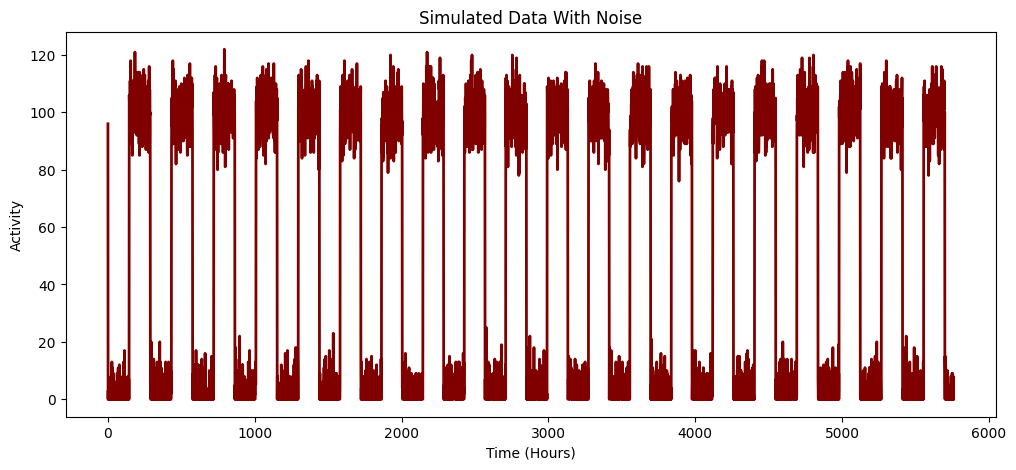

In [31]:
file_name = 'simulated_data'                                                                                            # Create the file name for the simulated data with noise
raw_data = chs.simulate_protocol(file_name, main_save_folder, sampling_frequency, days_per_stage, activity_period,
                                 signal_type = 'square', noise = True, snr_db = 20, only_positive = True,
                                 remove_file = True)      

#A oscilação vista no topo ou na parte baixa é referente ao ruido inserido no sinal. Caso o ruído seja retirado será uma onda quadrado 0 ou 1

fig = plt.figure(figsize = (12, 5))                                                                                     # Create a figure
ax = fig.add_subplot(111)                                                                                               # Add a subplot
ax.plot(raw_data, color = 'maroon', linewidth = 2)                                                                      # Plot the data with noise
ax.set_xlabel('Time (Hours)')                                                                                           # Set the x label
ax.set_ylabel('Activity')                                                                                               # Set the y label
ax.set_title('Simulated Data With Noise')                                                                               # Set the title
plt.show()  

In [33]:
len(raw_data)

5760

In [24]:
print(len(raw_data))

5760


Zeitgeber Time (ZT) é um conceito usado em cronobiologia para representar o tempo relativo a um estímulo externo cíclico (o zeitgeber, palavra alemã que significa "doador de tempo") que sincroniza o relógio biológico de um organismo — geralmente a luz.

🕒 O que é ZT na prática?
O tempo ZT0 representa o momento em que o estímulo sincronizador começa, normalmente o início da luz (luz acesa) em um ciclo claro-escuro (ex: 12h luz / 12h escuro).

ZT12 marca o início da fase escura.

📘 Exemplo com um ciclo de 12h luz / 12h escuro:
ZT	Significado
ZT0	Início do dia (luz acende)
ZT6	Meio do período de luz
ZT12	Início da noite (luz apaga)
ZT18	Meio da fase escura
ZT24 ≡ ZT0	Novo ciclo começa

🧬 Por que usar ZT?
Permite comparar ritmos biológicos (como expressão gênica, atividade, temperatura corporal) em diferentes condições experimentais.

Facilita a análise independente do tempo absoluto (ex: um experimento pode começar às 7h ou às 8h, mas ZT0 sempre marca "luz acesa").

🧠 Zeitgeber comuns:
Luz (principal para mamíferos)

Temperatura

Alimentação

Atividade física (em alguns organismos)



In [16]:
# simulation_file = 'insert/your/file/directory.asc                                                                       # If you want to use other dataset, please uncomment this line and set yout data path
simulation_file = main_save_folder + "/" + file_name + '.asc'                                                           # Set the path to the simulation description file

print('Data read from: ' + simulation_file)

## CONFIGURE THE EXPERIMENT --------------------------------------------------------------------------------------------

zt_0_time = 0                                                                                                           # Set the time for the first ZT (0)
type = 'generic'                                                                                                        # Set the type of the data decoding (endocrino or intellicage)
labels_dict = {'cycle_types': ['LD', 'DD', 'LD'], 'test_labels': ['A', 'B', 'C'], 'cycle_days': [5, 10, 5]}             # Create a dictionary to store to pass as argument to the read_protocol function

## CREATE THE PROTOCOL OBJECT WITH THE EXPERIMENT ----------------------------------------------------------------------

protocol = chr.read_protocol('simulation', simulation_file, zt_0_time = zt_0_time, labels_dict = labels_dict,
                             type = type, consider_first_day = True)                                                    # Read the protocol (chrono_reader.py)

print('\nTable generated after the data importing')
display(protocol.data)                                    

Data read from: ./output/simulated_data.asc

Table generated after the data importing


,values,is_night,cycle_types,test_labels,real_date,day
2022-01-01 00:00:00,89.0,False,LD,A,2022-01-01 00:00:00,2022-01-01
2022-01-01 00:05:00,0.0,False,LD,A,2022-01-01 00:05:00,2022-01-01
2022-01-01 00:10:00,0.0,False,LD,A,2022-01-01 00:10:00,2022-01-01
2022-01-01 00:15:00,10.0,False,LD,A,2022-01-01 00:15:00,2022-01-01
2022-01-01 00:20:00,0.0,False,LD,A,2022-01-01 00:20:00,2022-01-01
...,...,...,...,...,...,...
2022-01-20 23:35:00,0.0,True,LD,C,2022-01-20 23:35:00,2022-01-20
2022-01-20 23:40:00,0.0,True,LD,C,2022-01-20 23:40:00,2022-01-20
2022-01-20 23:45:00,5.0,True,LD,C,2022-01-20 23:45:00,2022-01-20
2022-01-20 23:50:00,2.0,True,LD,C,2022-01-20 23:50:00,2022-01-20


In [35]:
protocol

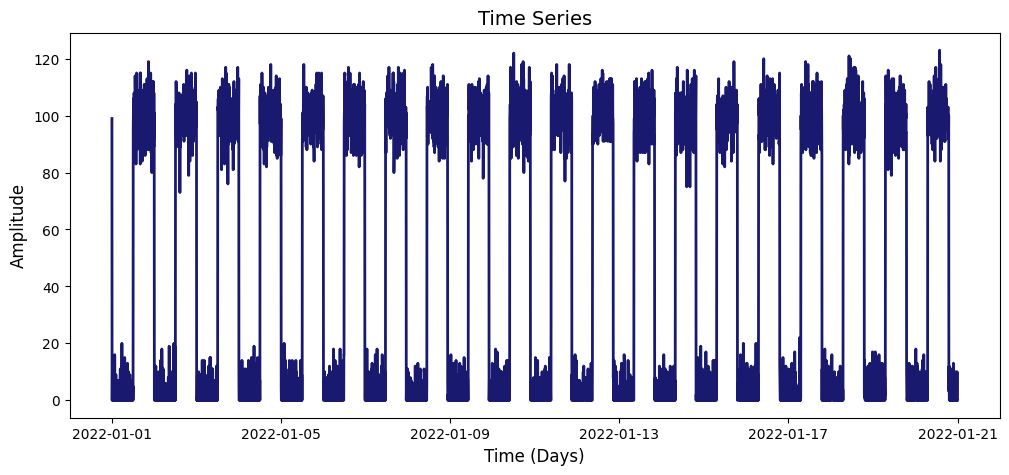

moving_average True


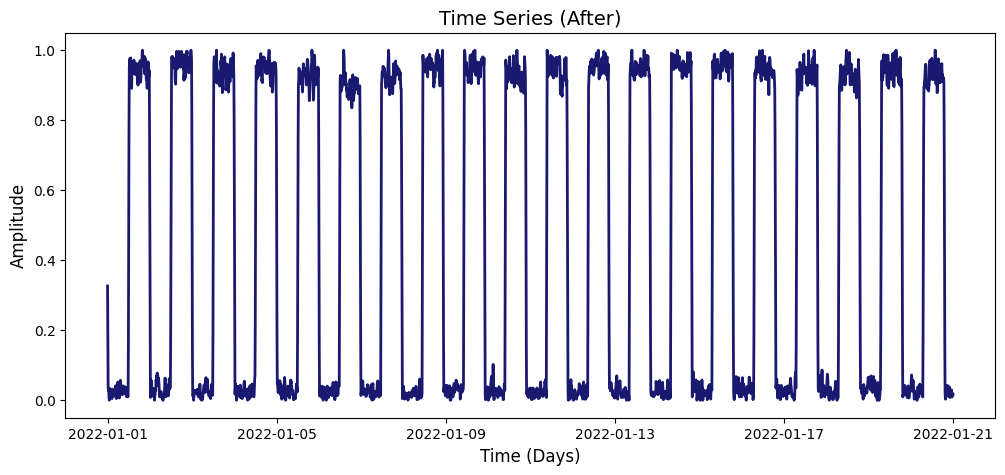

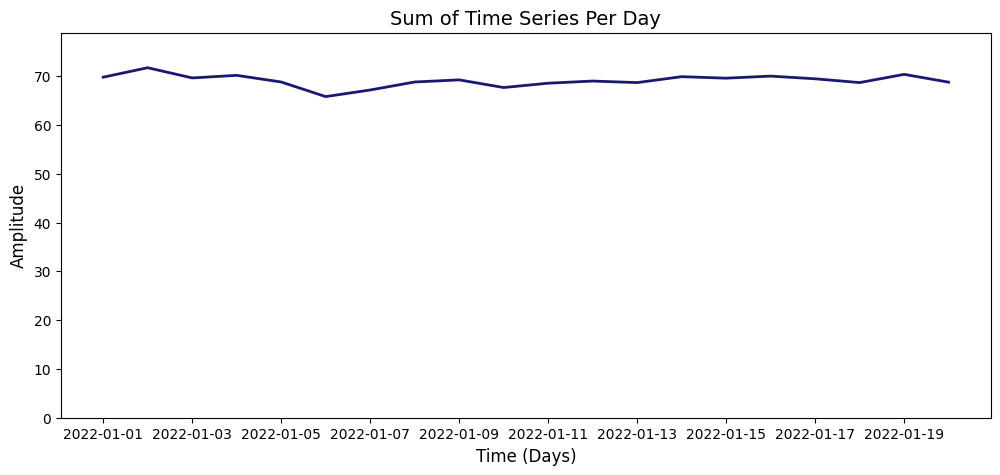

In [21]:
## PLOT THE DATA BEFORE PREPROCESSING ----------------------------------------------------------------------------------

chp.time_serie(protocol, labels = ['Time Series', 'Time (Days)', 'Amplitude'],
               color = 'midnightblue', save_folder = None, save_suffix = '')                                            # Plot the data (using chrono_plotter.py)


## RESAMPLE, FILTER AND NORMALIZE --------------------------------------------------------------------------------------

protocol.resample('10T', method = 'sum')                                                                                # Resample the data (chrono_reader.py)
protocol.apply_filter(window = 3, type = 'moving_average', order = 2, reverse = False)                                  # Apply a filter to the data (chrono_reader.py)
protocol.normalize_data(type = 'minmax', per_day = True)                                                                # Normalize the data (chrono_reader.py)

## PLOT THE DATA AFTER PREPROCESSING -----------------------------------------------------------------------------------

chp.time_serie(protocol, labels = ['Time Series (After)', 'Time (Days)', 'Amplitude'],
               color = 'midnightblue', save_folder = None, save_suffix = '')                                            # Plot the data (using chrono_plotter.py)
chp.time_serie_sum_per_day(protocol, labels = ['Sum of Time Series Per Day', 'Time (Days)', 'Amplitude'], color = 'midnightblue', save_folder = None, save_suffix = '')         # Plot the sum of the data per day (using chrono_plotter.py)

In this block, the pre-processed (or not) data will be submitted to a parameterization process of several cosine models. The user will select those periods (or frequencies) that he wants to test and, for each of them, the best model will be calculated and its parameters defined, being them: the amplitude, acrophase, mesor. At the end of this step, the best model among all the periods tested will be selected and its parameters used to characterize data. this process will be carried out for each stage separately. Internally, CircadiPy will organize the necessary table so that the CosinorPy library can run and estimate the best model, in addition, it will use the best model to produce graphs and tables representing the parameterization.

To set up the modeling, a dictionary (dict) will be used as parameter of the fit_cosinor function. In this dictionary the following variables should be configured.

The time_shape can be ‘continuous’, ‘meadian’ or ‘mean’. If it is ‘continuous’, all samples will be cosider to calculate the model. If it is ‘median’ or ‘mean’, the samples of activity will be grouped by mean/median along one day.

The step is the time step to calculate the model (in hours).

The start/end_time defines the period that the model will try to fit. E.g. if the start time is 24, the end time is 26, and the step is 0.5, the model will try to fit the data to a cosine curve with period equal to 24, 24.5, 25, 25.5 and 26 hours.

The n_components is the number of components that the model will try to fit. If it is a list, the model will try to fit all the number of components in the list. E.g. if n_components = [1,2,3], the model will try to fit the data with 1, 2 and 3 components.

Then, the best model obtained for each stage can be used to generate daily models. In this functionality, the period selected as the best model for each stage will be fixed and the acrophase, mesor and amplitude parameters will be obtained for each day.

Um modelo cosseno (ou modelo cosenoidal) é uma ferramenta matemática usada para descrever variações periódicas em dados — especialmente útil em análises de ritmos biológicos, como os ritmos circadianos.

O trecho que você mencionou descreve uma etapa comum na análise de séries temporais rítmicas, onde dados são ajustados a modelos baseados em função cosseno, testando diferentes períodos (ou frequências) para encontrar aquele que melhor representa o comportamento dos dados.

To set up the modeling, a dictionary (dict) will be used as parameter of the fit_cosinor function. In this dictionary the following variables should be configured.

The time_shape can be ‘continuous’, ‘meadian’ or ‘mean’. If it is ‘continuous’, all samples will be cosider to calculate the model. If it is ‘median’ or ‘mean’, the samples of activity will be grouped by mean/median along one day.

The step is the time step to calculate the model (in hours).

The start/end_time defines the period that the model will try to fit. E.g. if the start time is 24, the end time is 26, and the step is 0.5, the model will try to fit the data to a cosine curve with period equal to 24, 24.5, 25, 25.5 and 26 hours.

The n_components is the number of components that the model will try to fit. If it is a list, the model will try to fit all the number of components in the list. E.g. if n_components = [1,2,3], the model will try to fit the data with 1, 2 and 3 components.

Then, the best model obtained for each stage can be used to generate daily models. In this functionality, the period selected as the best model for each stage will be fixed and the acrophase, mesor and amplitude parameters will be obtained for each day.

In [22]:
dict = {'time_shape': 'continuous',
        'step': 0.01,
        'start_time': 22,
        'end_time': 26,
        'n_components': [1]}                                                                                            # Create a dictionary to pass as argument to the fit_cosinor function

## FIT THE COSINOR TO THE DATA -----------------------------------------------------------------------------------------

init = time.time()                                                                                                      # Get the initial time

best_models, best_models_file = chrt.fit_cosinor(protocol, dict = dict, save_folder = main_save_folder)                 # Fit the cosinor to the data (chrono_rithm.py)
best_models_fixed, best_models_fixed_file = chrt.fit_cosinor_fixed_period(protocol, best_models,
                                                                          save_folder = main_save_folder)               # Fix the best period calculated and fit the cosinor for each day using this period (chrono_rithm.py)

end = time.time() - init                                                                                                # Get the time elapsed

print("Cosinor fitted to " + protocol.name + " and results saved!")                                                     # Print that the cosinor was fitted and the results saved
print("Time elapsed: " + "{:.2f}".format(end) + " seconds")                                                             # Print the time elapsed

display(best_models)  

Cosinor fitted to simulation and results saved!
Time elapsed: 37.15 seconds


,significant,test,first_hour,period,n_components,p,q,p_reject,q_reject,amplitude,...,CI(acrophase),p(acrophase),q(acrophase),mesor,CI(mesor),p(mesor),q(mesor),acrophase_zt,acrophase_zt_lower,acrophase_zt_upper
0,1,A,0.0,24.14,1.0,1.110223e-16,1.157487e-16,NaN,NaN,0.584564,...,"[1.628973968528041, 1.7044476659115793]",0.0,0.0,0.486244,"[0.47266891255395593, 0.4998182582910585]",0.0,0.0,17.736496,17.591512,17.881481
1,1,B,0.0,23.52,1.0,1.110223e-16,1.157487e-16,1.110223e-16,NaN,0.585257,...,"[0.9245527929483464, 1.0000264903318863]",0.0,0.0,0.481834,"[0.4721244275388787, 0.4915441477888611]",0.0,0.0,19.917838,19.776577,20.059099
2,1,C,0.0,23.97,1.0,1.110223e-16,1.157487e-16,NaN,NaN,0.579155,...,"[2.6856057318975814, 2.7862373284089657]",0.0,0.0,0.482939,"[0.46961970111226675, 0.4962582895381454]",0.0,0.0,13.532613,13.340661,13.724565


In this section, we can compare the results of the cosinor fitting with the ground-truth period used to generate the simulated data. The mean and standard deviation (stage A, B and C) of the error between the period calculated by the cosinor fitting and the period used to generate the data is printed.

In [23]:

model_error = []                                                                                                        # Create an empty list to store the model error

activity_period_model = list(best_models['period'])                                                                     # Get the activity period calculated by the model
animal_model_error = [abs(a - b) for a,b in zip(activity_period_model, activity_period)]                                # Calculate the error between the model and the real activity period used to generate the data

model_error.extend(animal_model_error)                                                                                  # Store the model error in the list

print("Mean error: " + "{:.2f}".format(numpy.mean(model_error)) + " +/- " +
      "{:.2f}".format(numpy.std(model_error)) + " hours")     

Mean error: 0.06 +/- 0.05 hours


In [26]:
plot = False                                                                                                            # Set the plot parameter

if plot == False:                                                                                                        # If the plot parameter is False, save the images in the directory
    print("The plots will be saved in the folder: " + main_save_folder)
    save_folder = main_save_folder
else:
    print("The plots will be shown in the screen")
    save_folder = None      

The plots will be saved in the folder: ./output


In [27]:
chp.actogram_bar(protocol, first_hour = 18, save_folder = save_folder, save_suffix = 'bar')                             # Plot the actogram with bars (using chrono_plotter.py)
chp.actogram_colormap(protocol, first_hour = 18, save_folder = save_folder, save_suffix = 'colormap', norm_color = None)# Plot the actogram with colormap (using chrono_plotter.py)

## PLOT PERIODOGRAMS ---------------------------------------------------------------------------------------------------

chp.data_periodogram(protocol, time_shape = 'continuous', method = 'periodogram', max_period = 48,
                     unit_of_measurement = 'Amplitude', save_folder = save_folder, save_suffix = 'periodogram')         # Plot the periodogram (using chrono_plotter.py)
chp.data_periodogram(protocol, time_shape = 'continuous', method = 'welch', max_period = 48,
                     unit_of_measurement = 'Amplitude', save_folder = save_folder, save_suffix = 'welch')               # Plot the welch periodogram (using chrono_plotter.py)


In [26]:
chp.model_overview_detailed(protocol, best_models_fixed, save_folder = main_save_folder)                                # Plot representative parameters of the model fitted to the data for each day (using chrono_plotter.py)
chp.model_overview(protocol, best_models, save_folder = main_save_folder)                                               # Plot representative parameters of the model fitted to the data for each stage (using chrono_plotter.py)
chp.model_over_signal(protocol, best_models, position = 'head', mv_avg_window = 1, save_folder = main_save_folder)      # Plot representative figure with the data and the respective model (using chrono_plotter.py)

In [27]:
## SET THE PARAMETERS FOR THE COSINOR FITTING --------------------------------------------------------------------------

dict = {'day_window': 2,
        'step': 0.01,
        'start_time': 22,
        'end_time': 26,
        'n_components': [1]}                                                                                            # Create a dictionary to pass as argument to the fit_cosinor_per_day function

## FIT A COSINOR MODEL FOR EACH DAY ------------------------------------------------------------------------------------

best_models_per_day, best_models_fixed_file = chrt.fit_cosinor_per_day(protocol, dict = dict, plot = True,
                                                                       save_folder = save_folder)                       # Fit the cosinor to the data for each day or window of days (chrono_rithm.py)
